In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from anomaly_detection.models.scaled_SVDD_AE import AE_64

In [3]:
from anomaly_detection.config.paths import CHECKPOINT_DIR

checkpoint_1st_part = torch.load(os.path.join(CHECKPOINT_DIR, "acceptable_SVDD_no_bn_lam=10e-3_noBias_train_date=26-03_09-37", "SVDD_no_bn_lam=10e-6_noBias_ep241.pth"), map_location="cpu")

config = checkpoint_1st_part["config"]

model1 = AE_64()
model1.load_state_dict(checkpoint_1st_part["model_state_dict"])

model1.eval()

checkpoint_2nd_part = torch.load(os.path.join(CHECKPOINT_DIR, "CURRENT_SVDD_part_2_train_date=26-03_10-02", "CURRENT_SVDD_part_2_ep248.pth"), map_location="cpu")

model2 = AE_64()
model2.load_state_dict(checkpoint_2nd_part["model_state_dict"])

model2.eval()

AE_64(
  (encoder): Sequential(
    (0): Conv1d(1, 4, kernel_size=(4,), stride=(2,), padding=(1,), bias=False)
    (1): ReLU()
    (2): Conv1d(4, 16, kernel_size=(4,), stride=(2,), padding=(1,), bias=False)
    (3): ReLU()
    (4): Conv1d(16, 32, kernel_size=(2,), stride=(2,), bias=False)
    (5): ReLU()
    (6): Conv1d(32, 64, kernel_size=(6,), stride=(1,), bias=False)
    (7): Sigmoid()
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(64, 32, kernel_size=(6,), stride=(1,), bias=False)
    (1): ReLU()
    (2): ConvTranspose1d(32, 16, kernel_size=(2,), stride=(2,), bias=False)
    (3): ReLU()
    (4): ConvTranspose1d(16, 4, kernel_size=(4,), stride=(2,), padding=(1,), bias=False)
    (5): ReLU()
    (6): ConvTranspose1d(4, 1, kernel_size=(4,), stride=(2,), padding=(1,), bias=False)
    (7): Sigmoid()
  )
)

In [4]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [5]:
from anomaly_detection.utils.autoencoders import HistDataset
full_dataset = HistDataset(full_dataset)

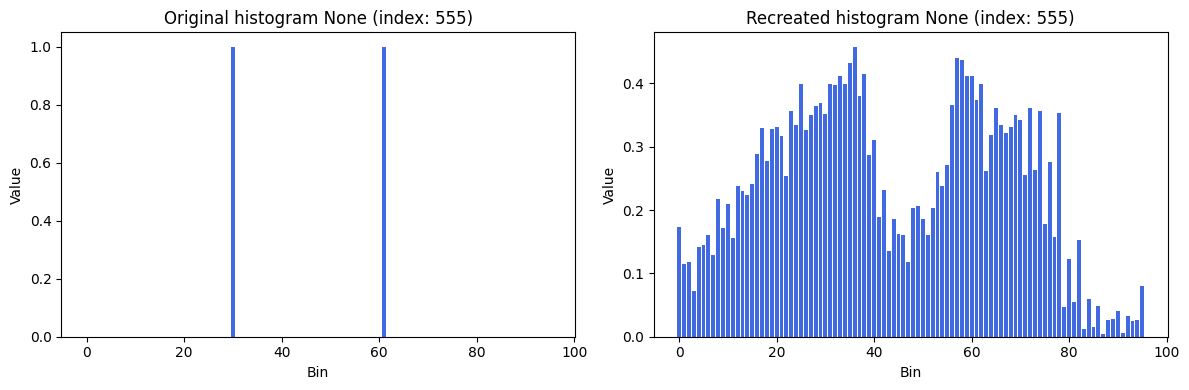

In [6]:
from anomaly_detection.utils.inspect_hist import plot_original_and_reconstructed

plot_original_and_reconstructed(model1, full_dataset, idx=555)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [8]:
pt = torch.tensor(full_dataset[0]).reshape(1,1,96)
model1.eval()
x = model1.encoder(pt)
print(x.shape)
print(torch.flatten(x).shape)

torch.Size([1, 64, 7])
torch.Size([448])


C:\Users\hrdyj\AppData\Local\Temp\ipykernel_37668\2336479338.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pt = torch.tensor(full_dataset[0]).reshape(1,1,96)


In [9]:
# center calculation
model1.eval()
embeddings = []

with torch.no_grad():  
    for data in X_train:
        data_tensor = torch.as_tensor(data, dtype=torch.float32).reshape(1, 1, 96)
        
        embed = model1.encoder(data_tensor)
        
        embeddings.append(embed.flatten())

embeddings_stack = torch.stack(embeddings)
center = torch.mean(embeddings_stack, dim=0)

Text(0.5, 1.0, 'Computed center of the hypersphere')

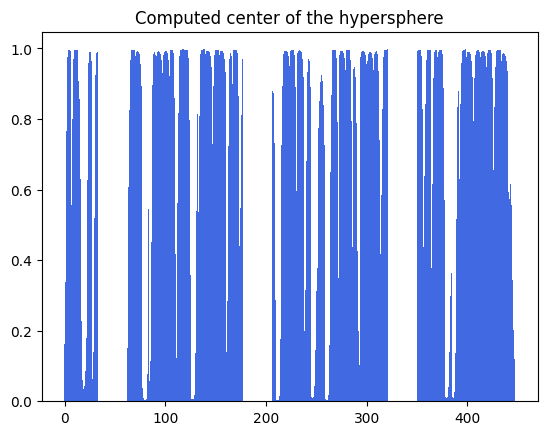

In [10]:
plt.bar(range(len(center)), center, color='royalblue')
plt.title("Computed center of the hypersphere")

In [11]:
import torch.nn as nn

def score_svdd(df, encoder, center=center, scoring_fct=nn.MSELoss()):
    scores = []
    with torch.no_grad():
        for pt in df:
            if not type(pt) == torch.Tensor:
                pt = torch.tensor(pt)

            pt = torch.flatten(encoder(pt.reshape(1,1,96)).detach())
            score = scoring_fct(pt, center)
            scores.append(score)
    return scores

In [12]:
import pandas as pd 
from anomaly_detection.config.paths import DATA_DIR
import os

eval_df = pd.read_parquet(os.path.join(DATA_DIR, 'eval_data', 'eval_dataset.parquet'))
eval_df = HistDataset(eval_df['histogram'].values)

In [13]:
scores = score_svdd(full_dataset, model1.encoder, center)
eval_score = score_svdd(eval_df, model1.encoder, center)

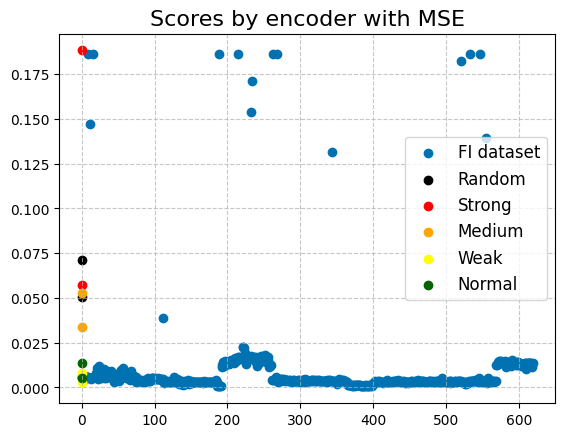

In [14]:
import matplotlib.pyplot as plt
from anomaly_detection.utils.plotting_styles import apply_global_style

apply_global_style()
plt.title("Scores by encoder with MSE")
plt.scatter(range(len(scores)), scores, label='FI dataset')
plt.scatter(range(len(eval_score[:2])), eval_score[:2], color='black', label='Random')
plt.scatter(range(len(eval_score[2:4])), eval_score[2:4], color='red', label='Strong')
plt.scatter(range(len(eval_score[4:6])), eval_score[4:6], color='orange', label='Medium')
plt.scatter(range(len(eval_score[6:8])), eval_score[6:8], color='yellow', label='Weak')
plt.scatter(range(len(eval_score[8:])), eval_score[8:], color='darkgreen', label='Normal')
plt.legend()

In [15]:
full_dataset = HistDataset(full_dataset)

In [16]:
scores = score_svdd(full_dataset, model2.encoder, scoring_fct=nn.MSELoss())
eval_score = score_svdd(eval_df, model2.encoder, scoring_fct=nn.MSELoss())

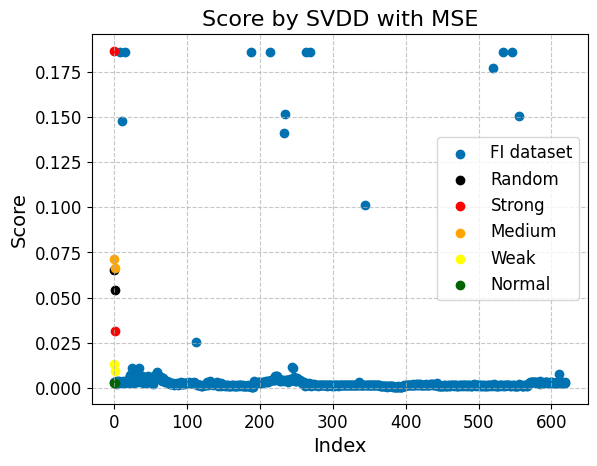

In [17]:
import matplotlib.pyplot as plt
from anomaly_detection.utils.plotting_styles import apply_global_style

apply_global_style()
plt.xlabel("Index")
plt.ylabel("Score")
plt.title("Score by SVDD with MSE")
plt.scatter(range(len(scores)), scores, label='FI dataset')
plt.scatter(range(len(eval_score[:2])), eval_score[:2], color='black', label='Random')
plt.scatter(range(len(eval_score[2:4])), eval_score[2:4], color='red', label='Strong')
plt.scatter(range(len(eval_score[4:6])), eval_score[4:6], color='orange', label='Medium')
plt.scatter(range(len(eval_score[6:8])), eval_score[6:8], color='yellow', label='Weak')
plt.scatter(range(len(eval_score[8:])), eval_score[8:], color='darkgreen', label='Normal')
plt.legend()

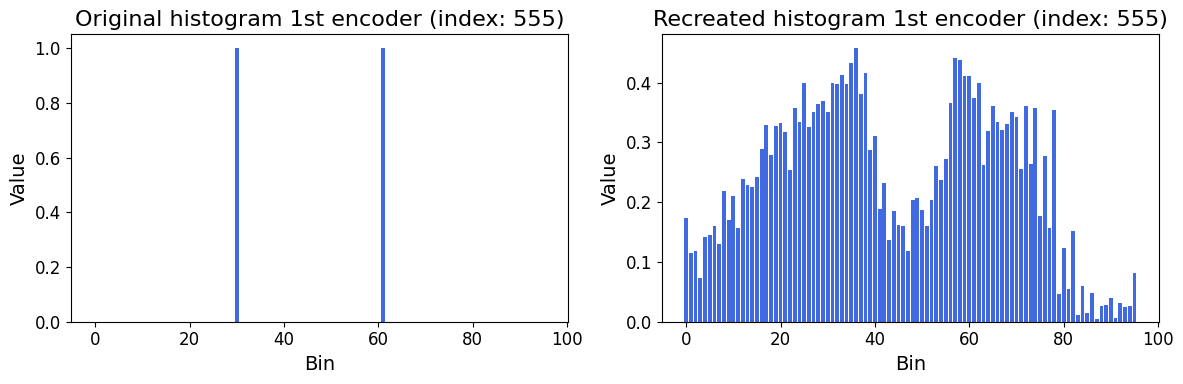

In [26]:
plot_original_and_reconstructed(model1, full_dataset, idx=555, title="1st encoder")

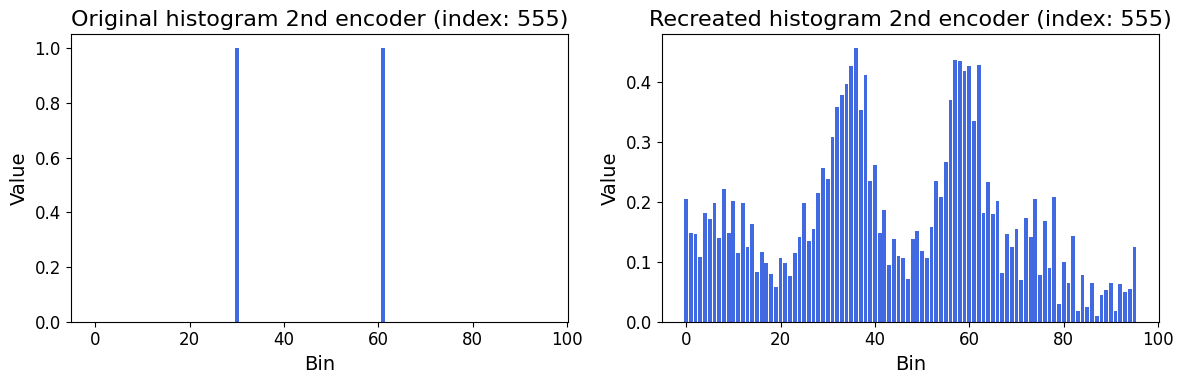

In [27]:
plot_original_and_reconstructed(model2, full_dataset, idx=555, title="2nd encoder")

In [38]:
from anomaly_detection.utils.scoring import QuantileScorer
q=0.99
scores = score_svdd(full_dataset, model2.encoder, scoring_fct=QuantileScorer(q))
eval_score = score_svdd(eval_df, model2.encoder, scoring_fct=QuantileScorer(q))

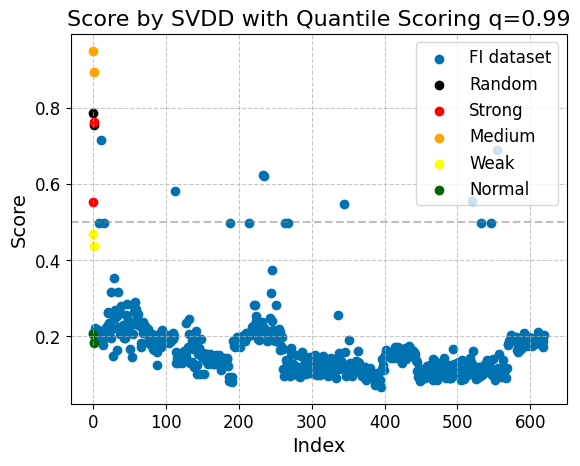

In [39]:
import matplotlib.pyplot as plt
from anomaly_detection.utils.plotting_styles import apply_global_style

apply_global_style()
plt.xlabel("Index")
plt.ylabel("Score")
plt.title(f"Score by SVDD with Quantile Scoring q={q}")
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.scatter(range(len(scores)), scores, label='FI dataset')
plt.scatter(range(len(eval_score[:2])), eval_score[:2], color='black', label='Random')
plt.scatter(range(len(eval_score[2:4])), eval_score[2:4], color='red', label='Strong')
plt.scatter(range(len(eval_score[4:6])), eval_score[4:6], color='orange', label='Medium')
plt.scatter(range(len(eval_score[6:8])), eval_score[6:8], color='yellow', label='Weak')
plt.scatter(range(len(eval_score[8:])), eval_score[8:], color='darkgreen', label='Normal')
plt.legend()